# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [ ]:
# Import the libraries we need
from PIL import Image, ImageOps
import numpy as np
from IPython.display import display


Image size: (512, 512)


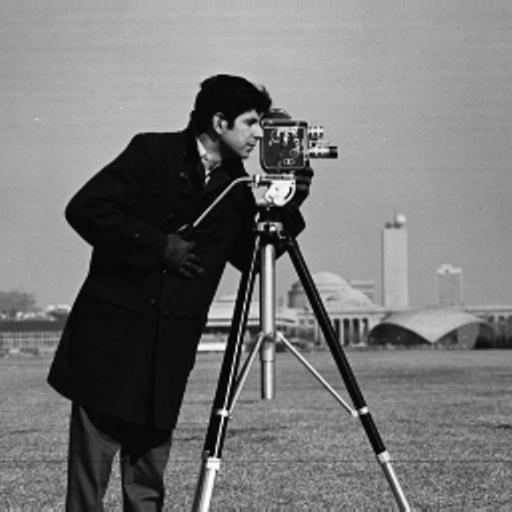

In [ ]:
# ── Load image ────────────────────────────────────
# The sample image from the original notebook was saved as lab3_input.jpg.
# If you want to use another image, just change the filename below.
img = Image.open("lab3_input.jpg")

print("Image size:", img.size)
display(img)


### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [ ]:
# Get the size of the image
width, height = img.size

# Scaling factors
cx = 2   # horizontal scale
cy = 2   # vertical scale

print("Original width:", width)
print("Original height:", height)


Original width: 512
Original height: 512


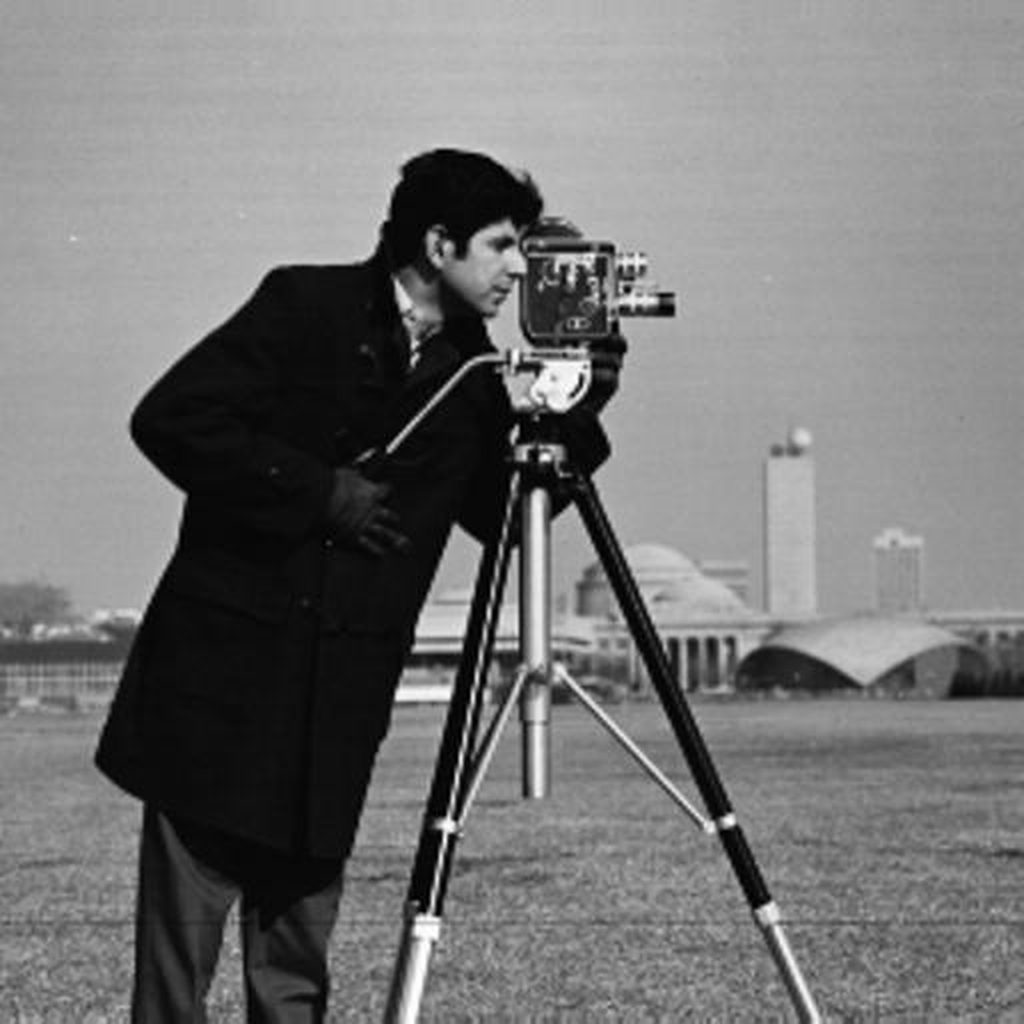

In [ ]:
# ── 1. Increase size (scale ×2) ────────────────────
# Multiply the original width and height by 2.
new_width = width * cx
new_height = height * cy

# Resize using LANCZOS for high-quality resampling.
scaled_img = img.resize((new_width, new_height), Image.Resampling.LANCZOS)

display(scaled_img)


In [ ]:
# Save the scaled image.
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)


Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [ ]:
# Non-uniform scaling: stretch horizontally only.
# cx = 2 means double the width.
# cy = 1 means keep the same height.
cx = 2
cy = 1

new_width = width * cx
new_height = height * cy


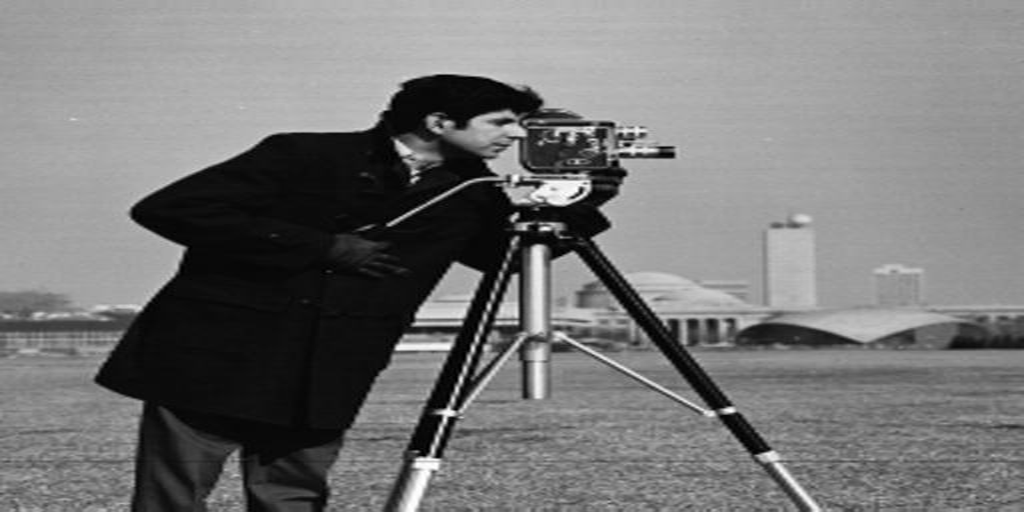

In [ ]:
# Resize using the new non-uniform dimensions.
horizontal_stretch = img.resize(
    (new_width, new_height),
    Image.Resampling.LANCZOS
)

display(horizontal_stretch)


In [ ]:
# Save the horizontally stretched image.
horizontal_stretch.save("task1_non_uniform_scaled.jpg")

print("Original size:", img.size)
print("New size:", horizontal_stretch.size)


Original size: (512, 512)
New size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size: (700, 700)


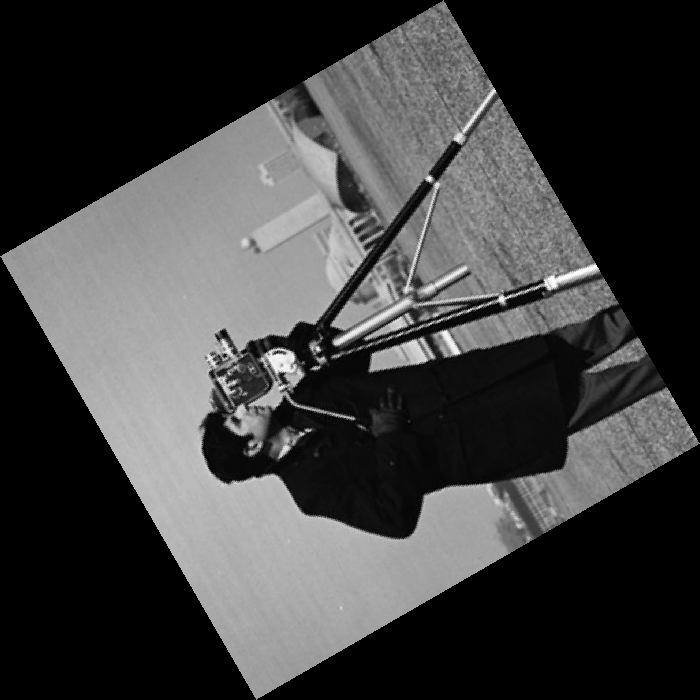

In [ ]:
# ── 2. Rotate 120 degrees ──────────────────────────
# expand=True makes the canvas large enough to show the whole rotated image.
rotated_img = img.rotate(120, expand=True)

rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated size:", rotated_img.size)
display(rotated_img)


### 3. Shear

In [ ]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size
print("Width:", width)
print("Height:", height)


Width: 512
Height: 512


In [ ]:
# -- d. Define the shear value ──────────────────────
# We will shear along the X-axis.
# A larger value gives a stronger slant.
shx = 0.5

# Increase the canvas width so the slanted image is not cut off.
new_width = int(width + abs(shx) * height)
new_height = height

print("Shear factor:", shx)
print("New canvas size:", (new_width, new_height))


Shear factor: 0.5
New canvas size: (768, 512)


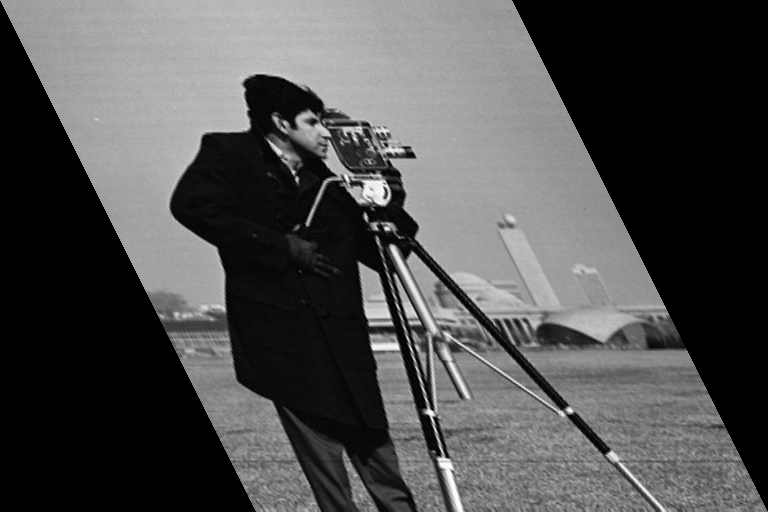

In [ ]:
# -- e. Apply the shear transformation ─────────────
# PIL uses inverse mapping for affine transformations.
# For an X-axis shear, we use -shx in the inverse matrix.
sheared_img = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0, 0, 1, 0),
    resample=Image.Resampling.BICUBIC
)

display(sheared_img)


In [ ]:
# -- f. Save the sheared image ──────────────────────
sheared_img.save("task1_3_sheared.jpg")
print("Saved as task1_3_sheared.jpg")


Saved as task1_3_sheared.jpg


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

**Notes for the shear experiment:**

- `shx = 0.1` gives a small slant.
- `shx = 0.3` gives a medium slant.
- `shx = 0.8` gives a stronger slant.
- For a Y-axis shear, increase the canvas height instead of the width and change the affine matrix accordingly.
- Positive and negative shear values slant the image in opposite directions.


# Intensity Transformations
Negative · Log · Power Law (Gamma)

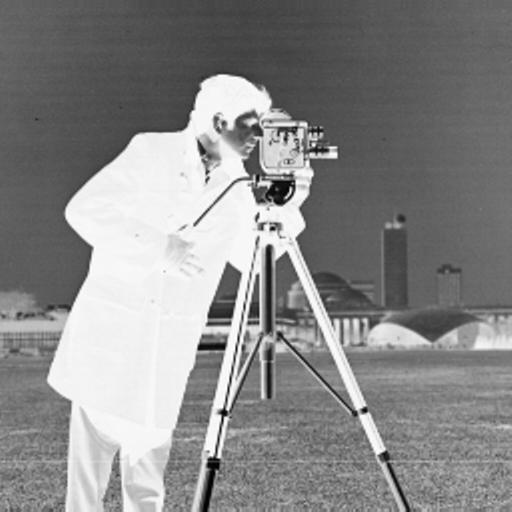

In [ ]:
# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation
# Negative image formula: new_pixel = 255 - old_pixel
arr = np.array(img)
negative_arr = 255 - arr
negative_img = Image.fromarray(negative_arr.astype(np.uint8))

negative_img.save("task2_1_negative_numpy.jpg")
display(negative_img)


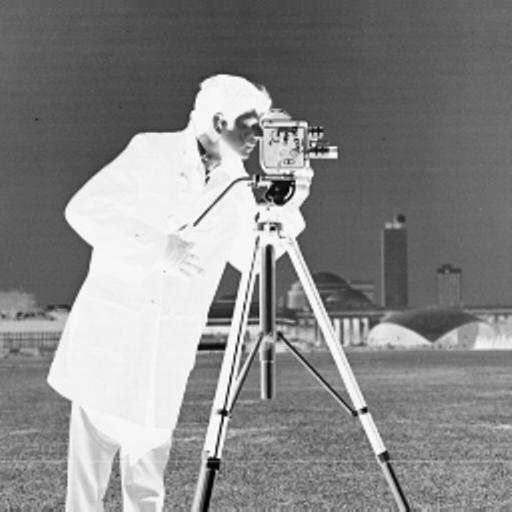

In [ ]:
# Method 2: PIL's ImageOps
# ImageOps.invert() performs the same negative transformation.
negative_pil = ImageOps.invert(img.convert("RGB"))

negative_pil.save("task2_1_negative_pil.jpg")
display(negative_pil)


c = 45.98590442833571


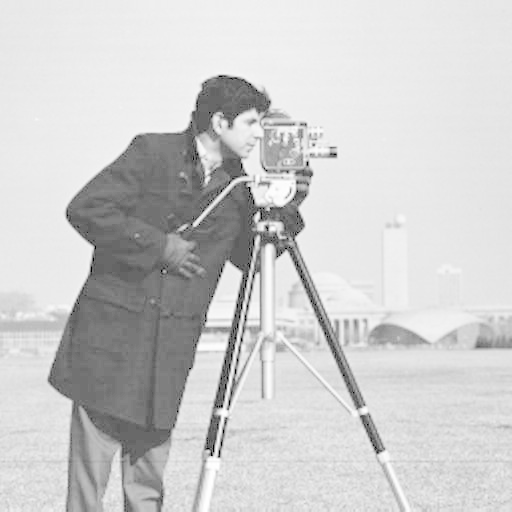

In [ ]:
# ── 2. Log transformation ──────────────────────────
# Formula: s = c * log(1 + r)
# We choose c so the maximum output value becomes 255.

# Convert to float first so calculations are safe.
arr = np.array(img).astype(np.float32)

c = 255 / np.log(1 + 255)
log_arr = c * np.log(1 + arr)

# Keep values in the valid image range and convert back to uint8.
log_arr = np.clip(log_arr, 0, 255).astype(np.uint8)
log_img = Image.fromarray(log_arr)

log_img.save("task2_2_log.jpg")
print("c =", c)
display(log_img)


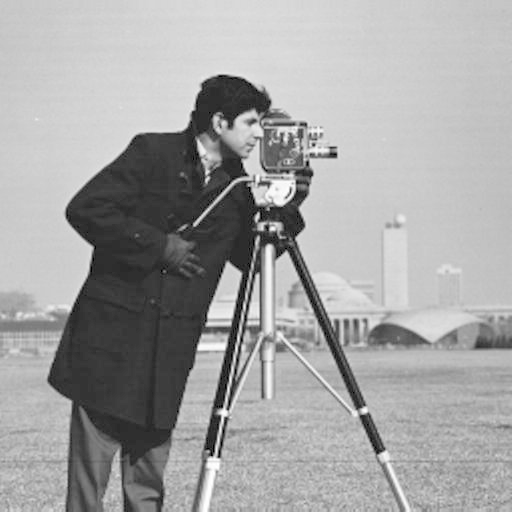

In [ ]:
# ── 3. Power-law / Gamma correction ───────────────
# Formula: s = 255 * (r / 255)^gamma
# gamma < 1 usually makes the image brighter.
# gamma > 1 usually makes the image darker.

gamma = 0.5

arr = np.array(img).astype(np.float32)
normalized = arr / 255.0

gamma_arr = 255 * (normalized ** gamma)
gamma_arr = np.clip(gamma_arr, 0, 255).astype(np.uint8)

gamma_img = Image.fromarray(gamma_arr)
display(gamma_img)


In [ ]:
# Save the gamma-corrected image.
gamma_img.save("task2_3_gamma.jpg")

print("Gamma value:", gamma)
print("Saved as task2_3_gamma.jpg")

# Try other values, for example:
# gamma = 0.3  -> brighter
# gamma = 1.0  -> almost unchanged
# gamma = 2.0  -> darker


Gamma value: 0.5
Saved as task2_3_gamma.jpg
